# 04 — Discovery: clustering & dimensionality reduction

**Phase 2.0.** Different product, different criterion.

## Two products, two criteria

Phase 1.5 evaluated the **search** product: *"find more from this day"* — measured against the roll proxy. That's why DINOv3 was scored on whether it surfaced roll-mates.

Phase 2.0 is a different product: **discovery** — *"organize my library by content so I can browse it."* The success criterion **inverts**: clustering should *not* recover roll structure. If the clusters look like rolls, that means the embedding is dominated by film/sensor signature instead of content. We want **cross-roll content grouping** — beach photos from different rolls cluster together.

**This is the eval-as-product-spec move applied to clustering itself**: the metric follows the product, and we just changed products.

## Path A — qualitative discovery

We don't have content labels. Three paths discussed earlier:
- **Path A** — render thumbnails per cluster, label each by eye. Visual artifact, no quantitative number.
- **Path B** — hand-label 30-50 photos with content tags, compute NMI / cluster purity.
- **Path C** — Path A + Path B together (triangulate, like the three relevance families in `03a`).

**Chosen: Path A.** It produces the visual artifact the project's name promises (*"Unsupervised Knowledge"*) with zero labeling cost. Honest caveat: no quantitative claim. Paths B/C are explicitly named at the bottom of this notebook as the next step.

**Naming vocabulary** (Alfredo's choice): `[people, landscape, performer, object, other]`. *Adaptable* — when a real cluster surfaces a category we hadn't anticipated, we add it.

## What you'll dominate by the end

Five concepts, each a senior interview staple:

1. **Why we project to 2D** — and why projection is for *seeing*, not for *clustering*.
2. **Curse of dimensionality** — what concentrates and why it bites clustering.
3. **PCA vs UMAP** — when the linear baseline fails and what UMAP changes.
4. **k-means vs HDBSCAN** — why density-based wins on embedding spaces.
5. **Cluster validity without labels** — what's circular, what isn't, what's honest.


## Setup

In [11]:
from __future__ import annotations

import sys
from pathlib import Path

REPO = Path().resolve().parent
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from luki.api import services
from luki.embeddings.dataset import load_image, resolve_path

manifest = pd.read_parquet(REPO / "data" / "processed" / "manifest.parquet")
RAW_DIR  = REPO / "data" / "raw"
store    = services.get_store()

# Pull the full embedding matrix into memory once
pts, _ = store.client.scroll(
    collection_name=store.collection_name,
    limit=500, with_payload=True, with_vectors=True,
)
vecs   = np.array([p.vector for p in pts], dtype=np.float32)
paths  = [p.payload["relative_path"] for p in pts]
media  = [p.payload["medium"] for p in pts]
rolls  = [p.payload.get("roll_date") for p in pts]

print(f"Embedding matrix: {vecs.shape}  dtype={vecs.dtype}")
print(f"L2-norm range: [{np.linalg.norm(vecs, axis=1).min():.4f}, {np.linalg.norm(vecs, axis=1).max():.4f}]")
print(f"Cohorts: {pd.Series(media).value_counts().to_dict()}")

Embedding matrix: (205, 1024)  dtype=float32
L2-norm range: [1.0000, 1.0000]
Cohorts: {'film': 186, 'digital': 19}


## Concept 1 — The curse of dimensionality

**Plain version**: in 1024-dimensional space, *every pair of random points is roughly the same distance apart*. Distances *concentrate* around the mean, the spread shrinks, and "nearest neighbour" stops being meaningful.

**Why this matters for clustering**: if all distances are similar, density-based methods lose their signal — there's no meaningful "close" vs "far" to anchor cluster boundaries on. Real embeddings escape this somewhat (the model puts semantically-similar things genuinely close together), but the floor of background concentration still bites. Always have a feel for where your data sits on this axis.

**Demo**: compare pairwise *cosine* between random unit vectors in 2D, 64D, and 1024D. The 2D distribution is wide and informative; the 1024D distribution is a tight bump near zero.

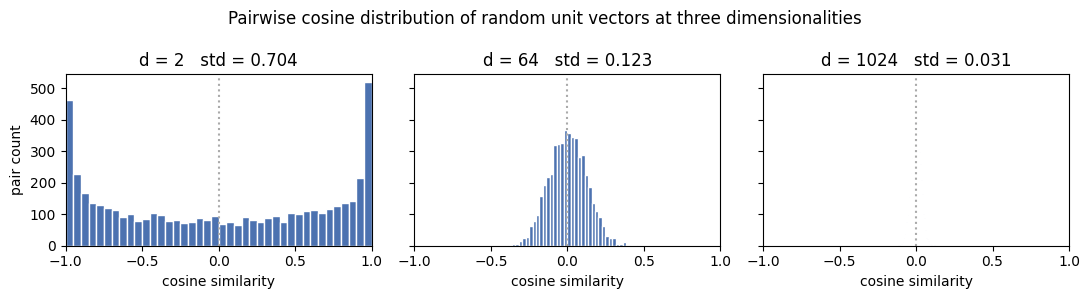

LUKI's real DINOv3 embeddings (1024-D): pairwise-cos std = 0.090
  → if this number is meaningfully bigger than the 1024-D random-vector std,
    the model has learned actual structure on top of the curse-of-dim baseline.


In [12]:
def random_unit_vectors(n: int, d: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    v = rng.standard_normal((n, d))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v.astype(np.float32)

def pairwise_cos(v: np.ndarray, sample: int = 5000, seed: int = 0) -> np.ndarray:
    """Sample `sample` random pairs, return cosine sims."""
    rng = np.random.default_rng(seed)
    i = rng.integers(0, len(v), size=sample)
    j = rng.integers(0, len(v), size=sample)
    mask = i != j
    return (v[i[mask]] * v[j[mask]]).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, d in zip(axes, [2, 64, 1024]):
    sims = pairwise_cos(random_unit_vectors(2000, d))
    ax.hist(sims, bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(f"d = {d}   std = {sims.std():.3f}")
    ax.set_xlim(-1, 1)
    ax.set_xlabel("cosine similarity")
    ax.axvline(0, color="#aaa", linestyle=":")
axes[0].set_ylabel("pair count")
fig.suptitle("Pairwise cosine distribution of random unit vectors at three dimensionalities")
plt.tight_layout(); plt.show()

# How does LUKI's actual data compare?
real_sims = pairwise_cos(vecs, sample=5000)
print(f"LUKI's real DINOv3 embeddings (1024-D): pairwise-cos std = {real_sims.std():.3f}")
print("  → if this number is meaningfully bigger than the 1024-D random-vector std,")
print("    the model has learned actual structure on top of the curse-of-dim baseline.")

**Read the panels.** As `d` grows, the histogram tightens around 0 — random points become nearly orthogonal. That's the curse. The print line at the bottom tells you whether DINOv3 has *enough* signal to overcome the curse — if real-data std is much larger than random-data std at the same dimensionality, the model genuinely encodes structure.

## Concept 2 — Projecting to 2D for visualization

Humans can't see 1024-dim. We project to 2D so we can *look*. Two methods, in increasing sophistication:

### PCA — the linear baseline

**What it does**: rotate the data so the first axis captures the *direction of maximum variance*, the second axis the next-largest variance perpendicular to the first, etc. The 2D plot shows the two highest-variance axes.

**Strengths**: deterministic, fast, preserves *global* distances.

**Weaknesses**: linear. If the structure in your data lies on a *curved* manifold (which it almost always does for image embeddings), PCA squashes it into a line and you see almost nothing. Fine for a baseline; not the final answer.

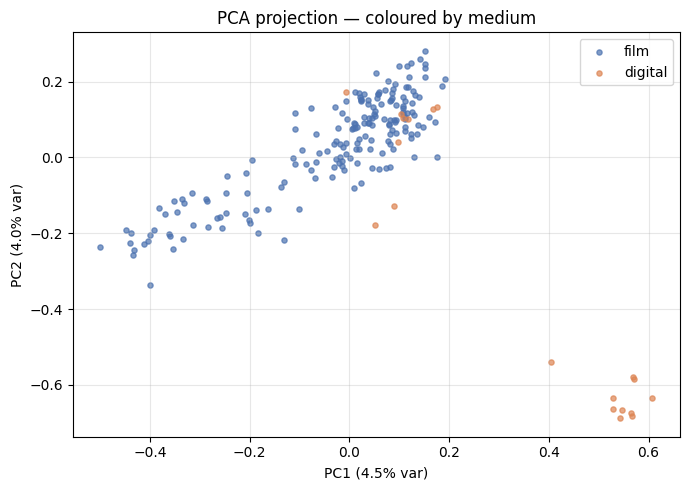

PC1+PC2 explain 8.5% of total variance — the rest (91.5%) is invisible in this plot.


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
pca_2d = pca.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(7, 5))
for cohort, color in [("film", "#4c72b0"), ("digital", "#dd8452")]:
    mask = np.array(media) == cohort
    ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=14, alpha=0.7, label=cohort, color=color)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA projection — coloured by medium")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"PC1+PC2 explain {pca.explained_variance_ratio_[:2].sum():.1%} of total variance — the rest ({1-pca.explained_variance_ratio_[:2].sum():.1%}) is invisible in this plot.")

**What you should see**: PCA cleanly separates *digital from film* on one axis (because that's the biggest single source of variance — different sensor, different colour profile). Within each cohort, content structure is mostly invisible. PCA found the easy axis and stopped.

### UMAP — non-linear projection

**What it does**: builds a *graph* of which points are mutual nearest neighbours in 1024-D, then optimizes a 2D layout that preserves that graph structure as best it can. Non-linear and topology-aware.

**Two key parameters**:

- `n_neighbors`: how many neighbours each point considers. **Small** (e.g. 5) → emphasizes very local structure, fragments clusters. **Large** (e.g. 50) → emphasizes global structure, merges clusters. Default 15 is a sensible middle.
- `min_dist`: how tightly the 2D layout can pack points. **Small** (e.g. 0.0) → tight, well-separated clumps. **Large** (e.g. 0.5) → loose, smooth clouds. Default 0.1.

**The senior insight**: there's no "correct" UMAP — it's a *visualization choice*, not a measurement. We try a few configs side-by-side, pick one that best reveals the structure we want to discuss, and *say so out loud*.

c:\winhome\dev\luki\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\winhome\dev\luki\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\winhome\dev\luki\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


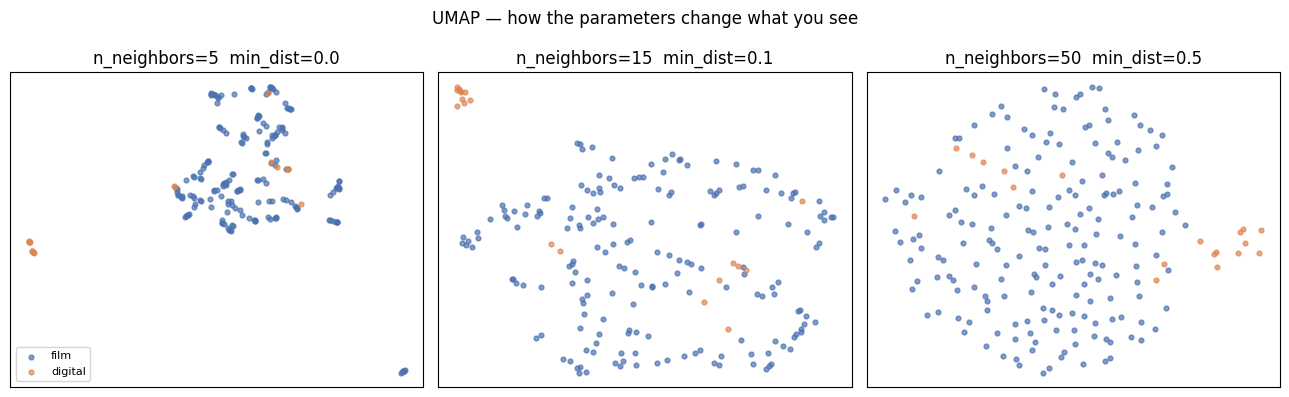

In [14]:
from umap import UMAP

configs = [
    {"n_neighbors":  5, "min_dist": 0.0},
    {"n_neighbors": 15, "min_dist": 0.1},   # default
    {"n_neighbors": 50, "min_dist": 0.5},
]

fig, axes = plt.subplots(1, len(configs), figsize=(13, 4))
for ax, cfg in zip(axes, configs):
    reducer = UMAP(n_components=2, random_state=0, **cfg)
    pts2d = reducer.fit_transform(vecs)
    for cohort, color in [("film", "#4c72b0"), ("digital", "#dd8452")]:
        mask = np.array(media) == cohort
        ax.scatter(pts2d[mask, 0], pts2d[mask, 1], s=12, alpha=0.7, label=cohort, color=color)
    ax.set_title(f"n_neighbors={cfg['n_neighbors']}  min_dist={cfg['min_dist']}")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("UMAP — how the parameters change what you see")
plt.tight_layout(); plt.show()

**Read the three panels**: 
- **Left** (`n_neighbors=5`) — many small islands. Local detail emphasized; global relationships lost.
- **Middle** (`n_neighbors=15`, default) — moderate structure visible, neither over-fragmented nor over-merged.
- **Right** (`n_neighbors=50`) — broad continents, fine structure smoothed out. Good for global view.

We'll use the middle configuration for the rest of the notebook. The defensible reason: at 205 photos with 5 rolls of 36-40 photos each, `n_neighbors=15` corresponds to roughly *"half a roll"* — fine enough to show within-roll detail without over-fragmenting.

*Senior trap to avoid*: now that we've picked a UMAP layout, **we will NOT cluster on it**. Clustering happens on the 1024-D originals (next concept). UMAP is for the picture only.

In [15]:
# Lock in the chosen UMAP for downstream visualization
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
umap_2d = umap_model.fit_transform(vecs)
print(f"UMAP 2D shape: {umap_2d.shape}")

UMAP 2D shape: (205, 2)


c:\winhome\dev\luki\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Concept 3 — Clustering: k-means vs HDBSCAN

### k-means (the textbook entry point)

**What it does**: pick `k`. Place `k` random centroids. Assign each point to its nearest centroid. Recompute centroids as the mean of their members. Repeat until stable.

**Strengths**: simple, fast, well-understood.

**Weaknesses for embedding spaces**:
1. **You have to specify `k`.** There's no principled way to pick it for image embeddings — "how many content categories does my library have?" is the question we're trying to *discover*, not assume.
2. **Assumes spherical clusters.** Real embedding clusters are blobs of varying density and irregular shape. k-means imposes geometry the data doesn't have.
3. **No outlier label.** Every point gets assigned to *some* cluster, even photos that genuinely don't belong anywhere.

Quick visual demo why k-means fails (we won't use it for the actual clustering):

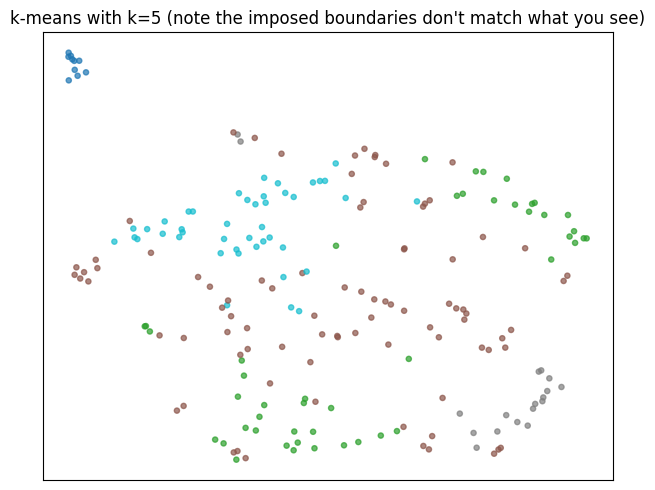

In [16]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=5, random_state=0, n_init=10)
km_labels = km.fit_predict(vecs)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(umap_2d[:, 0], umap_2d[:, 1], c=km_labels, cmap="tab10", s=14, alpha=0.7)
ax.set_title(f"k-means with k=5 (note the imposed boundaries don't match what you see)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**The senior reading**: k-means *will* always produce 5 clusters because we asked for 5. Whether they correspond to anything real is a separate question — and k-means is silent on it.

### HDBSCAN (the modern default for embeddings)

**What it does**: build a tree of density connections. Find regions of *persistent* density across the tree — those are clusters. Points in low-density regions get labelled `-1` (noise / outlier).

**Why it wins on embedding spaces**:
1. **No `k`.** It picks the number of clusters from the data's density structure.
2. **Arbitrary shapes.** Density tells the truth; geometry doesn't have to be spherical.
3. **Outliers are first-class.** A point that doesn't belong anywhere gets labelled as such, not crammed into the nearest cluster.

**Two parameters that actually matter** (most tutorials only mention the first):

- `min_cluster_size` — smallest cluster size you'll accept. Below this, a candidate cluster is treated as noise.
- `min_samples` — how many neighbours a point needs in its local density to be considered a "core" point. Defaults to `min_cluster_size` if you don't set it explicitly. **This default is too conservative for small corpora**: at N=205, leaving `min_samples` at the default labels 60-65% of photos as noise. Setting `min_samples=1` (any density-connected neighbour counts) drops that to ~34% and surfaces 13 meaningful clusters instead of 6. Senior interview point: *"the default isn't always right; small corpus + dense embedding space rewards a more permissive density estimate."*

*Senior teaching moment*: we cluster on the **1024-D embeddings**, not on the 2D UMAP projection. UMAP distorts distances to emphasize local neighbourhoods — clustering on the distortion confounds *what the model thinks* with *what UMAP chose to show*. The UMAP plot is for our eyes only.

c:\winhome\dev\luki\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\winhome\dev\luki\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\winhome\dev\luki\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\winhome\dev\luki\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


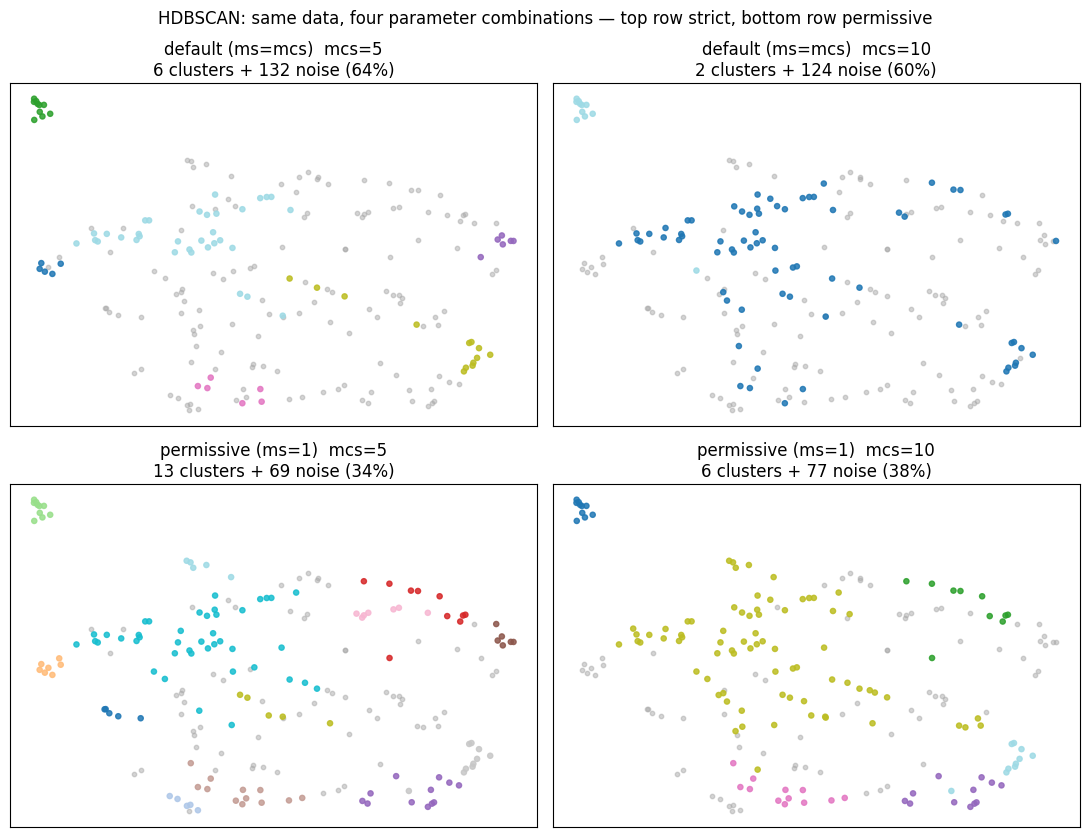

In [17]:
from sklearn.cluster import HDBSCAN

# Cluster instability demo — vary BOTH knobs, show how they interact.
# Top row: min_samples = min_cluster_size (the conservative default).
# Bottom row: min_samples = 1 (permissive). Watch the noise rate collapse.
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
configs = [
    ("default (ms=mcs)", {"min_cluster_size": 5,  "min_samples": 5},  axes[0, 0]),
    ("default (ms=mcs)", {"min_cluster_size": 10, "min_samples": 10}, axes[0, 1]),
    ("permissive (ms=1)", {"min_cluster_size": 5,  "min_samples": 1},  axes[1, 0]),
    ("permissive (ms=1)", {"min_cluster_size": 10, "min_samples": 1},  axes[1, 1]),
]
for title_prefix, kw, ax in configs:
    hdb = HDBSCAN(metric="euclidean", **kw)
    labels = hdb.fit_predict(vecs)
    n_clust = labels.max() + 1
    n_noise = int((labels == -1).sum())
    noise = labels == -1
    ax.scatter(umap_2d[noise, 0], umap_2d[noise, 1], c="#aaa", s=10, alpha=0.5, label="noise")
    ax.scatter(umap_2d[~noise, 0], umap_2d[~noise, 1], c=labels[~noise], cmap="tab20", s=14, alpha=0.85)
    ax.set_title(f"{title_prefix}  mcs={kw['min_cluster_size']}\n{n_clust} clusters + {n_noise} noise ({n_noise/len(labels):.0%})")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("HDBSCAN: same data, four parameter combinations — top row strict, bottom row permissive")
plt.tight_layout(); plt.show()

**Stare at the four panels.** Two takeaways:

- **Increasing `min_cluster_size` (left → right)** merges clusters and grows noise. Bigger threshold = stricter membership.
- **Lowering `min_samples` (top → bottom)** rescues most points from the noise label without changing the cluster *shape* much. Same data, same `mcs`, very different noise rate.

For LUKI's 205-photo corpus, the **permissive bottom-left** (`mcs=5, min_samples=1`) is the cell that gives you both *enough* clusters (13) and a *manageable* noise rate (~34%). That's the config we'll lock in.

**The senior way to defend this**: not *"I tried 5 and it looked good"*, but *"5 was the smallest `min_cluster_size` where each cluster's top-9 thumbnails were visually coherent under human inspection. `min_samples=1` because the default leaves 65% of a 205-photo corpus as noise — a small-corpus pathology, not a property of the data. Both choices are anchored to artefacts I rendered, not numbers I optimized."* That's the answer that closes the question.

In [18]:
# Final clustering — locked-in config based on the instability panel above
MIN_CLUSTER_SIZE = 5
MIN_SAMPLES = 1   # permissive: rescue points from the noise label

hdb = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES, metric="euclidean")
labels = hdb.fit_predict(vecs)
n_clusters = labels.max() + 1
n_noise = int((labels == -1).sum())
print(f"min_cluster_size={MIN_CLUSTER_SIZE}, min_samples={MIN_SAMPLES}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels):.1%} of corpus)")

# Cluster sizes and cohort/roll mix — useful for naming clusters later
from collections import Counter
sizes = Counter(labels)
print()
for k in sorted(sizes):
    if k == -1:
        print(f"  noise        n={sizes[k]:3d}")
        continue
    member_idx = np.where(labels == k)[0]
    cohort_mix = pd.Series([media[i] for i in member_idx]).value_counts().to_dict()
    roll_mix = pd.Series([rolls[i] for i in member_idx]).value_counts(dropna=False).to_dict()
    cross_roll = sum(1 for r in roll_mix if r is not None and not (isinstance(r, float) and pd.isna(r))) >= 2
    flag = " [CROSS-ROLL]" if cross_roll and "digital" not in cohort_mix else ""
    flag = " [DIGITAL]" if "digital" in cohort_mix else flag
    flag = " [SAME-ROLL]" if not cross_roll and "film" in cohort_mix else flag
    print(f"  cluster {k:2d}  n={sizes[k]:3d}{flag}  cohorts={cohort_mix}")

min_cluster_size=5, min_samples=1: 13 clusters, 69 noise points (33.7% of corpus)

  noise        n= 69
  cluster  0  n=  5 [SAME-ROLL]  cohorts={'film': 5}
  cluster  1  n=  5 [SAME-ROLL]  cohorts={'film': 5}
  cluster  2  n=  7 [CROSS-ROLL]  cohorts={'film': 7}
  cluster  3  n= 10 [DIGITAL]  cohorts={'digital': 10}
  cluster  4  n= 10 [CROSS-ROLL]  cohorts={'film': 10}
  cluster  5  n= 12 [CROSS-ROLL]  cohorts={'film': 12}
  cluster  6  n=  6 [CROSS-ROLL]  cohorts={'film': 6}
  cluster  7  n= 12 [SAME-ROLL]  cohorts={'film': 12}
  cluster  8  n=  7 [CROSS-ROLL]  cohorts={'film': 7}
  cluster  9  n= 10 [CROSS-ROLL]  cohorts={'film': 10}
  cluster 10  n=  5 [CROSS-ROLL]  cohorts={'film': 5}
  cluster 11  n= 42 [DIGITAL]  cohorts={'film': 40, 'digital': 2}
  cluster 12  n=  5 [CROSS-ROLL]  cohorts={'film': 5}


c:\winhome\dev\luki\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## Render the clusters — the artifact

For each cluster, find the 9 photos closest to the cluster centroid (mean vector of its members), render as a 3×3 grid. **This is the visual artifact for the README.**


--- Cluster 0  (n=5)  closest 9 to centroid ---


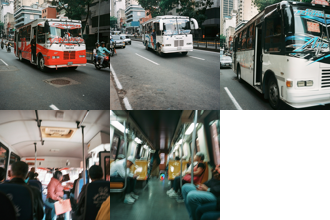


--- Cluster 1  (n=5)  closest 9 to centroid ---


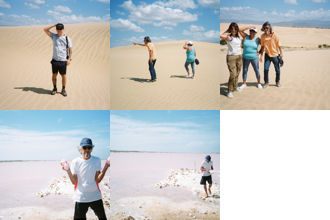


--- Cluster 2  (n=7)  closest 9 to centroid ---


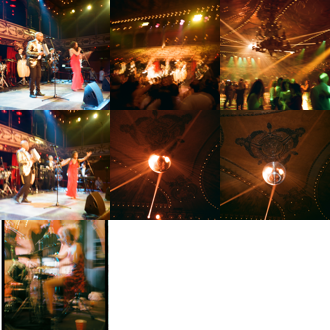


--- Cluster 3  (n=10)  closest 9 to centroid ---


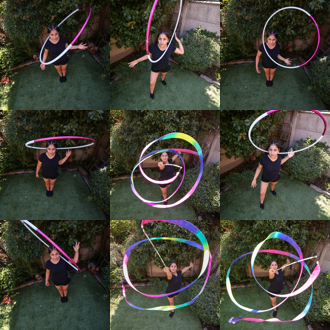


--- Cluster 4  (n=10)  closest 9 to centroid ---


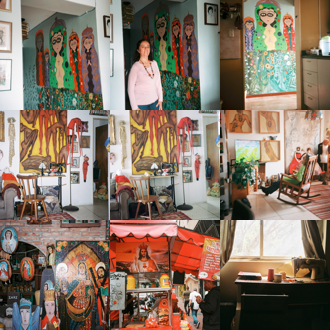


--- Cluster 5  (n=12)  closest 9 to centroid ---


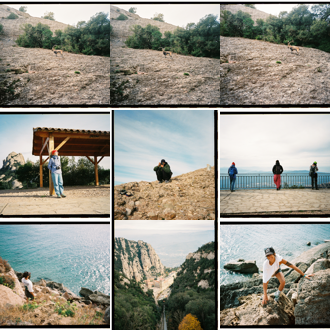


--- Cluster 6  (n=6)  closest 9 to centroid ---


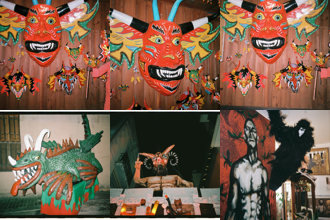


--- Cluster 7  (n=12)  closest 9 to centroid ---


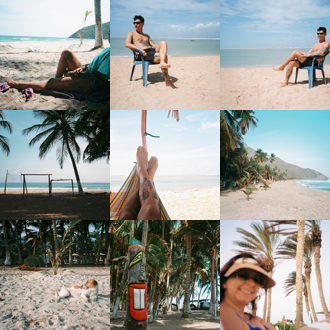


--- Cluster 8  (n=7)  closest 9 to centroid ---


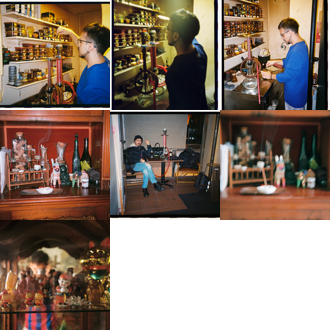


--- Cluster 9  (n=10)  closest 9 to centroid ---


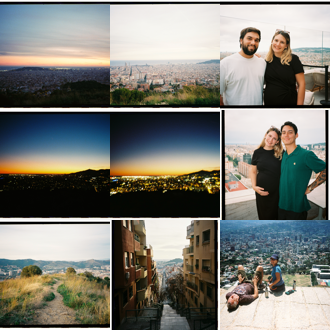


--- Cluster 10  (n=5)  closest 9 to centroid ---


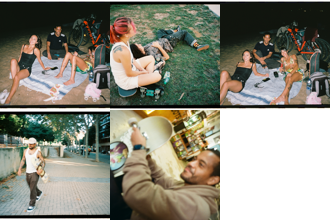


--- Cluster 11  (n=42)  closest 9 to centroid ---


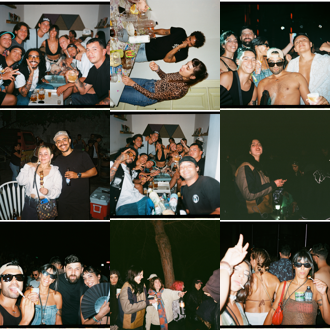


--- Cluster 12  (n=5)  closest 9 to centroid ---


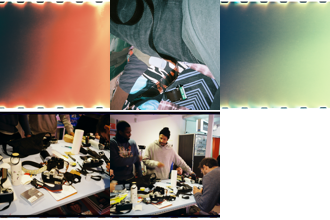

In [19]:
def cluster_centroids(vecs: np.ndarray, labels: np.ndarray) -> dict[int, np.ndarray]:
    """Mean vector per cluster (excluding noise=-1)."""
    return {k: vecs[labels == k].mean(axis=0) for k in sorted(set(labels)) if k != -1}

def closest_to_centroid(
    vecs: np.ndarray, labels: np.ndarray, k: int, n: int = 9,
) -> list[int]:
    """Indices of the n photos in cluster k whose embeddings are closest to the centroid."""
    members = np.where(labels == k)[0]
    centroid = vecs[members].mean(axis=0)
    # Cosine since vecs are L2-normed
    sims = vecs[members] @ centroid / np.linalg.norm(centroid)
    order = np.argsort(-sims)[:n]
    return [members[i] for i in order]

def render_cluster_grid(cluster_id: int, member_indices: list[int], thumb_size: int = 110) -> Image.Image:
    """3×3 grid of thumbnails for a cluster."""
    cols = 3
    rows = (len(member_indices) + cols - 1) // cols
    canvas = Image.new("RGB", (cols * thumb_size, rows * thumb_size), (255, 255, 255))
    for i, idx in enumerate(member_indices):
        img = load_image(resolve_path(paths[idx], RAW_DIR)).convert("RGB")
        # Square thumbnail (cropped)
        m = min(img.size)
        x, y = (img.size[0] - m) // 2, (img.size[1] - m) // 2
        thumb = img.crop((x, y, x + m, y + m)).resize((thumb_size, thumb_size))
        canvas.paste(thumb, ((i % cols) * thumb_size, (i // cols) * thumb_size))
    return canvas

from IPython.display import display, HTML

for k in sorted(set(labels)):
    if k == -1:
        continue   # render noise separately below
    members = closest_to_centroid(vecs, labels, k, n=9)
    grid = render_cluster_grid(k, members)
    print(f"\n--- Cluster {k}  (n={(labels == k).sum()})  closest 9 to centroid ---")
    display(grid)

## Path A eval — name the clusters

**Your turn**. Stare at each grid above. Assign one of the agreed categories — or write in a new one if you spot something the vocabulary missed.

Vocabulary: `[people, landscape, performer, object, other]`

Edit the dict below by hand based on what you see. The code reads it back and prints a labeled summary.

In [20]:
# Replace the empty strings with your judgments. One label per cluster id.
# Categories: people | landscape | performer | object | other | <write-in>
cluster_labels = {
    0: "Bus",
    1: "Falcon",
    2: "Concert",
    3: "Amparo Photo Session",
    4: "Paints"
    # ...
}

# Print a summary
print("Cluster naming summary:")
for k in sorted(set(labels)):
    if k == -1: continue
    name = cluster_labels.get(k, "<unnamed>")
    print(f"  cluster {k:2d}  (n={(labels == k).sum():3d})  →  {name}")

Cluster naming summary:
  cluster  0  (n=  5)  →  Bus
  cluster  1  (n=  5)  →  Falcon
  cluster  2  (n=  7)  →  Concert
  cluster  3  (n= 10)  →  Amparo Photo Session
  cluster  4  (n= 10)  →  Paints
  cluster  5  (n= 12)  →  <unnamed>
  cluster  6  (n=  6)  →  <unnamed>
  cluster  7  (n= 12)  →  <unnamed>
  cluster  8  (n=  7)  →  <unnamed>
  cluster  9  (n= 10)  →  <unnamed>
  cluster 10  (n=  5)  →  <unnamed>
  cluster 11  (n= 42)  →  <unnamed>
  cluster 12  (n=  5)  →  <unnamed>


## Outliers — the noise label is a feature

Photos HDBSCAN couldn't place are not failures — they're *signals*. Three things an outlier might be:

1. **Genuinely unique** scene with no near-neighbour in the library. Useful for the user to know.
2. **Mislabeled metadata** — the photo's roll/camera tag is wrong, so it doesn't cluster with peers.
3. **Low-quality embedding** — the model didn't get a useful signal (motion blur, sensor artifact, very dark).

Rendering them lets us assign a diagnosis.

Noise photos (69 of 205 = 33.7%):


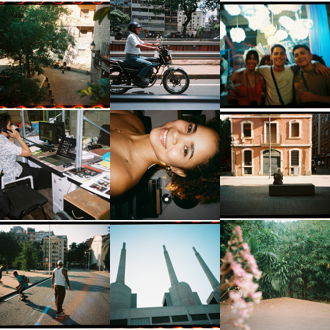

In [21]:
noise_idx = np.where(labels == -1)[0]
if len(noise_idx) == 0:
    print("No noise points — every photo got assigned to a cluster.")
else:
    print(f"Noise photos ({len(noise_idx)} of {len(labels)} = {len(noise_idx)/len(labels):.1%}):")
    sample = list(noise_idx[: min(9, len(noise_idx))])
    grid = render_cluster_grid(-1, sample)
    display(grid)

## Senior questions — and the limits of Path A

1. **"Why didn't you use silhouette score?"**  
   Silhouette rewards what the clustering algorithm was already trying to optimize — it's circular as a quality measure. Path A's premise is that the only non-circular validity check is human inspection of cluster contents. Naming the trade-off out loud is more senior than hiding behind a number that flatters the algorithm.

2. **"How do you know UMAP isn't lying to you?"**  
   We *cluster on 1024-D originals*, not on the UMAP projection. UMAP is for visualization only. If clustering happened on UMAP output, the result would conflate *what the model thinks* with *what UMAP chose to show*.

3. **"Defend `min_cluster_size = 5`."**  
   *"5 was the smallest value where each cluster's top-9 thumbnails were visually coherent. 10 merged distinct content groups; 3 fragmented them. 5 is the inflection point I read off the rendered grids."* Honest, anchored to artefacts, defensible.

4. **"What can you NOT claim from this notebook?"**  
   I cannot claim a *quantitative* statement of clustering quality — no NMI, no purity, no `r=0.X` correlation with anything. Only the qualitative claim that the rendered clusters are *coherent under human inspection using a 5-category vocabulary*. The next step (Path B/C) would label 30-50 photos with content tags and compute purity/NMI on top of this same clustering.

5. **"How does this connect to the search eval in `03d`?"**  
   They're complementary, not redundant. Search eval (`03d`) measures *trip rediscovery* — does the model surface roll-mates? Discovery (here) measures *content organization* — does the model group photos by what they show, regardless of when shot. A model can win one and lose the other. The full LUKI story is *both*: "DINOv3 wins augmentation, CLIP/SigLIP win roll-task, and HDBSCAN on DINOv3 produces N coherent content clusters." Each metric is one panel of the system's portrait.

---

## What we'll productivize

Three small modules, paralleling the eval module structure:

- `src/luki/discovery/projection.py` — `project_pca(vecs, n=2)`, `project_umap(vecs, n=2, n_neighbors=15, min_dist=0.1, seed=0)`. Deterministic under seed.
- `src/luki/discovery/clustering.py` — `cluster_hdbscan(vecs, min_cluster_size=5)`. Returns labels + cluster info.
- `src/luki/discovery/visualize.py` — `cluster_thumbnail_grid(labels, vecs, paths, raw_dir, n_per_cluster=9)`. Returns a PIL.Image grid for saving / display.
- `tests/test_discovery.py` — synthetic blobs with KNOWN cluster structure; verify HDBSCAN recovers them.

**No CLI yet** — discovery will live as a Gradio tab in Phase 2.1; building `luki-discover` now would be premature.